In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.utils.data as dataloader
import torchvision

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [22]:
print(device)

cuda


--- Running Fixed Model ---
Raw Logits from model: tensor([[-0.3011, -0.1000, -0.0021]], grad_fn=<AddmmBackward0>)
Standard Softmax Output:
 tensor([[0.2800, 0.3424, 0.3776]], grad_fn=<SoftmaxBackward0>) 

--- Applying Temperature-Scaled Softmax with Visualization ---
Visualization saved as 'temperature_scaling_bar_plot.png'.


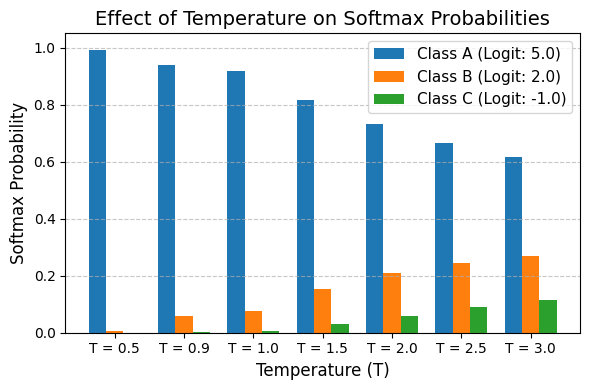

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- 1. Fixed Neural Network Code ---
class SimpleClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 8)
        self.fc2 = nn.Linear(8, 3)   # 3 classes

    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)
        logits = self.fc2(x)         # These are the raw logits
        
        print("Raw Logits from model:", logits)
        
        # BUG FIX: Added dim=1. Without this, PyTorch throws an error.
        # dim=1 means "calculate probabilities across the 3 classes"
        probabilities = torch.softmax(logits, dim=1) 
        
        return probabilities

model = SimpleClassifier()
x = torch.randn(1, 4)

print("--- Running Fixed Model ---")
op = model(x)
print("Standard Softmax Output:\n", op, "\n")


# --- 2. Temperature-Scaled Softmax Visualization ---
import matplotlib.pyplot as plt
import numpy as np

print("--- Applying Temperature-Scaled Softmax with Visualization ---")

# Example raw logits (e.g., extracted right before the softmax layer in a real model)
raw_logits = torch.tensor([[4.0, 1.5, -1.0]])
class_labels = ["Class A (Logit: 5.0)", "Class B (Logit: 2.0)", "Class C (Logit: -1.0)"]

# Discrete temperatures for a grouped bar chart
temperatures = [0.5, 0.9,1.0,1.5, 2.0,2.5, 3.0]
probabilities = []

# Calculate probabilities for each temperature
for t in temperatures:
    scaled_logits = raw_logits / t
    probs = F.softmax(scaled_logits, dim=1)
    probabilities.append(probs.squeeze().numpy())

probabilities = np.array(probabilities)

# Plotting the visualization as a grouped bar chart
plt.figure(figsize=(6,4))

x = np.arange(len(temperatures))  # the label locations
width = 0.25  # the width of the bars

for i in range(raw_logits.shape[1]):
    # Offset the x position for each class to group the bars by temperature
    plt.bar(x + (i - 1) * width, probabilities[:, i], width, label=class_labels[i])

# Formatting the plot
plt.title("Effect of Temperature on Softmax Probabilities", fontsize=14)
plt.xlabel("Temperature (T)", fontsize=12)
plt.ylabel("Softmax Probability", fontsize=12)
plt.xticks(x, [f"T = {t}" for t in temperatures])
plt.ylim(0.0, 1.05)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()

# Save and optionally display the plot
plot_filename = "temperature_scaling_bar_plot.png"
plt.savefig(plot_filename)
print(f"Visualization saved as '{plot_filename}'.")
# plt.show() # Uncomment this line to display the plot interactively if your environment supports it

In [24]:
#Preprocessing
transforms_cifar = transforms.Compose([transforms.ToTensor(),
transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),])

# Loading the CIFAR-10 dataset:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms_cifar)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms_cifar)

Files already downloaded and verified
Files already downloaded and verified


In [25]:
train_dl = dataloader.DataLoader(train_dataset,batch_size=16,shuffle=True)
val_dl = dataloader.DataLoader(train_dataset,batch_size=16,shuffle=True)

In [26]:
class TeacherModel(nn.Module):
    """A large, powerful model (e.g., ResNet-34)"""
    def __init__(self, num_classes=10):
        super(TeacherModel, self).__init__()
        # Using a pre-trained ResNet as teacher
        self.model = torchvision.models.resnet34(pretrained=True)
        # Replace the final layer for our number of classes
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
    
    def forward(self, x):
        return self.model(x)

#### Note:In a normal neural network, the model output layer gives logits, not softmax. Then during training CrossEntropyLoss internally handles softmax.

In [27]:
class StudentModel(nn.Module):
    """A small, lightweight model (e.g., a simple CNN)"""
    def __init__(self, num_classes=10):
        super(StudentModel, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [28]:
def train(model, train_loader, epochs, learning_rate, device):
    criterion = nn. CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            # inputs: A collection of batch_size images
            # labels: A vector of dimensionality batch_size with integers denoting class of each image
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            # outputs: Output of the network for the collection of images. A tensor of dimensionality batch_size x num_classes
            # labels: The actual labels of the images. Vector of dimensionality batch_size
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss / len(train_loader)}")

In [29]:
def test(model, test_loader, device):
    model.to(device)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy :.2f}%")
        

In [30]:
torch.manual_seed(42)
nn_deep = TeacherModel(num_classes=10).to(device)
train(nn_deep, train_dl, epochs=10, learning_rate=0.001, device=device)
test_accuracy_deep = test(nn_deep, val_dl, device)

/DATA/pranta_2411ai09/miniconda/envs/memeinterpret/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/DATA/pranta_2411ai09/miniconda/envs/memeinterpret/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /DATA/pranta_2411ai09/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:01<00:00, 55.2MB/s]


Epoch 10/10, Loss: 0.487032981672287
Test Accuracy: 71.53%


In [31]:
import torch.nn.functional as F

def train_student_kd(
    student, teacher, train_loader,
    epochs=10, lr=1e-3, device="cuda",
    T=3.0, alpha=0.7
):
    teacher.eval()          # teacher fixed
    student.train()

    optimizer = torch.optim.Adam(student.parameters(), lr=lr)
    ce_loss = nn.CrossEntropyLoss()
    kd_loss = nn.KLDivLoss(reduction="batchmean")

    for epoch in range(epochs):
        total_loss = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            with torch.no_grad():
                teacher_logits = teacher(inputs)

            student_logits = student(inputs)

            # 1. Hard-label loss
            loss_ce = ce_loss(student_logits, labels)

            # 2. Soft-label distillation loss
            teacher_soft = F.softmax(teacher_logits / T, dim=1)
            student_log_soft = F.log_softmax(student_logits / T, dim=1)

            loss_kd = kd_loss(student_log_soft, teacher_soft) * (T * T)

            # Final combined loss
            loss = alpha * loss_kd + (1 - alpha) * loss_ce

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

In [32]:
student = StudentModel(num_classes=10).to(device)

train_student_kd(
    student=student,
    teacher=nn_deep,
    train_loader=train_dl,
    epochs=10,
    lr=0.001,
    device=device,
    T=3.0,
    alpha=0.7
)

test(student, val_dl, device)

Epoch 1/10, Loss: 2.3761
Epoch 2/10, Loss: 1.5408
Epoch 3/10, Loss: 1.3441
Epoch 4/10, Loss: 1.2231
Epoch 5/10, Loss: 1.1458
Epoch 6/10, Loss: 1.0892
Epoch 7/10, Loss: 1.0513
Epoch 8/10, Loss: 1.0100
Epoch 9/10, Loss: 0.9813
Epoch 10/10, Loss: 0.9563
Test Accuracy: 74.86%
